<a href="https://colab.research.google.com/github/ijazkhan0351-bot/Ijazweek1-ml-assignment/blob/main/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ijazkhan0351-bot/Ijazweek1-ml-assignment/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
%pip install -q duckdb huggingface_hub

import duckdb
from google.colab import userdata
import pandas as pd
import numpy as np
import os
import json
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression

HF_TOKEN = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")
REL = "hf://datasets/FlyRank/internship-warehouse"
print("Connected.")

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

# Rebuild Week 5 model + data
march = con.sql(f"""
    SELECT client_hash_id, content_hash_id,
        AVG(gsc_impressions) as avg_impressions,
        AVG(gsc_clicks) as avg_clicks,
        AVG(gsc_avg_position) as avg_position,
        SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0) as ctr
    FROM read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
    HAVING SUM(gsc_impressions) > 0
""").df()

april = con.sql(f"""
    SELECT client_hash_id, content_hash_id, SUM(gsc_clicks) as april_clicks
    FROM read_parquet('{REL}/fact_content_daily_performance/month=2026-04/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
""").df()

data = march.merge(april, on=["client_hash_id", "content_hash_id"], how="inner")
data["is_declining"] = (data["april_clicks"] < data["avg_clicks"] * 30 * 0.85).astype(int)

feature_cols = ["avg_impressions", "avg_clicks", "avg_position", "ctr"]
X = data[feature_cols].fillna(0)
y = data["is_declining"]
groups = data["client_hash_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
data_test = data.iloc[test_idx].copy()

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train, y_train)
data_test["model_score"] = logreg.predict_proba(X_test)[:, 1]
p50 = precision_at_k(data_test["model_score"], y_test.values, 50)
print(f"Model rebuilt. Precision@50 = {p50:.3f}")

Connected.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Model rebuilt. Precision@50 = 0.940


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## Ranked Actions + Reason Codes

Using the Week-5 model score, I assign each page a reason code and action
label based on which signals dominate its risk profile — this maps model
output to the same archetype→action logic FlyRank's own playbook uses
(Refresh, Fix CTR, Monitor).

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
def assign_action(row):
    if row["avg_position"] > 20:
        return "poor_ranking", "review_ranking_strategy"
    elif row["ctr"] < data["ctr"].median() and row["avg_impressions"] > data["avg_impressions"].median():
        return "high_impressions_low_ctr", "fix_ctr_snippet"
    elif row["model_score"] > 0.6:
        return "high_decline_risk", "priority_refresh"
    else:
        return "stable", "monitor"

data_test[["reason_code", "action_label"]] = data_test.apply(
    lambda r: pd.Series(assign_action(r)), axis=1
)

ranked_queue = data_test[["content_hash_id", "client_hash_id", "model_score",
                            "reason_code", "action_label", "avg_impressions",
                            "avg_position", "ctr"]].sort_values("model_score", ascending=False)

print("=== Action label distribution ===")
print(ranked_queue["action_label"].value_counts())
print("\n=== Top 10 ranked actions ===")
ranked_queue.head(10)

=== Action label distribution ===
action_label
monitor                    13836
review_ranking_strategy     5356
priority_refresh            4043
Name: count, dtype: int64

=== Top 10 ranked actions ===


,content_hash_id,client_hash_id,model_score,reason_code,action_label,avg_impressions,avg_position,ctr
156449,content_266a53be5f02ef38,client_2094c6eb080311d5,1.0,high_decline_risk,priority_refresh,1.000000,5.000000,0.500000
158407,content_52d26fc5cffe2f17,client_1a730cb2640a1abf,1.0,high_decline_risk,priority_refresh,1.000000,0.000000,1.000000
144919,content_c185f1a7f92e0412,client_3f0ce4d44fe94f3d,1.0,high_decline_risk,priority_refresh,1.000000,4.666667,0.333333
63866,content_656fa3469dd0425a,client_0fa64a184f18a4a0,1.0,high_decline_risk,priority_refresh,1.333333,2.666667,0.250000
139448,content_9d0d97080c811f65,client_0fa64a184f18a4a0,1.0,high_decline_risk,priority_refresh,1.333333,4.166667,0.250000
156476,content_9e556a3124ab6b0e,client_2094c6eb080311d5,1.0,poor_ranking,review_ranking_strategy,2.000000,20.833333,0.250000
141411,content_db748889c83b48a1,client_3f0ce4d44fe94f3d,1.0,high_decline_risk,priority_refresh,1.000000,5.400000,0.200000
155947,content_7fba977f2461b8c1,client_1a730cb2640a1abf,1.0,high_decline_risk,priority_refresh,1.666667,4.777778,0.200000
78614,content_69a9e969984e57fe,client_1a730cb2640a1abf,1.0,high_decline_risk,priority_refresh,2.500000,3.375000,0.200000
72262,content_16ab208d3ac13b4e,client_0fa64a184f18a4a0,1.0,high_decline_risk,priority_refresh,2.500000,4.250000,0.200000


**Archetype → Action mapping:**
- **High decline risk, good position, decent volume** → Priority Refresh
  (this is the FlyRank "growth engine" pattern from the research paper:
  recently-updated pages in the right age band recover fastest)
- **High impressions, low CTR, any position** → Fix CTR / snippet review
  (matches the paper's CTR-cliff finding — position and CTR interact, but
  a low-CTR high-visibility page is a fast, cheap fix)
- **Poor position (20+)** → Review ranking strategy — likely needs more than
  a refresh; may need backlinks, restructuring, or deprioritization
- **Everything else** → Monitor — not urgent, revisit next cycle

**The decay/refresh insight:** Consistent with the research paper's Finding
4 (Freshness Multiplier), pages flagged as high-risk that are also older
(higher content_age proxy via lower recent update signal) are the best
refresh candidates — refreshing a page that's merely young and having a
bad month is lower-value than refreshing one that's genuinely stale.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
## Intended Use and Limits

**Intended use:** This playbook is a **decision-support tool** for a content
editor or SEO strategist prioritizing which pages to review first each
month. It is meant to narrow a large page library down to a manageable,
ranked shortlist — not to make refresh decisions automatically.

**Limits:**
- The model is trained on one client-grouped slice of one month's data
  (March→April); it has not been validated across multiple time windows,
  so its precision may drift in later months.
- The label (is_declining) is a proxy based on a click-drop threshold, not
  a ground-truth measure of "needs refresh" — a page can decline for
  reasons a refresh won't fix (seasonality, a competitor outranking it,
  an algorithm update).
- Predictions are observed, directional patterns in this sample — not
  causal claims, and not guarantees for any individual page.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## Human Review + No-Go List

**Human review is required before any action is taken.** This tool ranks
and flags — it does not publish, rewrite, or change anything automatically.

**What should NOT be automated:**
1. **Actually rewriting or publishing content changes** — the model has no
   understanding of brand voice, factual accuracy, or legal/compliance risk.
2. **Deprioritizing or pruning a page based on model score alone** — a low
   score doesn't mean "abandon"; a human should confirm before removing
   any client-facing content from active support.
3. **Client-facing reporting or claims built directly on model scores** —
   raw scores are internal prioritization signals, not something to show
   a client as "your page is 73% likely to decline."
4. **Any action on pages flagged with very small sample support** (e.g.
   clients with thin March/April history) — the model's confidence is
   lowest exactly where the stakes of being wrong are highest for a small
   client relationship.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
## Monitoring and Retrain Triggers

**Light monitoring plan:**
- Track Precision@50 monthly on a fresh, unseen month — if it drops more
  than ~15% relative to the Week-5/6 baseline, that's a retrain signal.
- Track the action-label distribution over time — if "priority_refresh"
  suddenly balloons or shrinks dramatically month over month, investigate
  before trusting the queue (could signal a data pipeline issue, not a
  real shift).
- Spot-check a random sample of 10 "monitor" (low-priority) pages each
  month to confirm the model isn't systematically missing a declining
  segment.

**Retrain triggers:**
- A new month's held-out Precision@50 falls below a set floor (e.g. 0.30).
- A structural change in the underlying data (new clients onboarded, a
  tracked metric definition changes) that could shift feature distributions.
- Quarterly, regardless of performance — to keep the model current with
  seasonal and platform changes.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Queue exported: 23235 rows
Metrics JSON saved:
{
  "week": "w07_action_playbook",
  "model_precision_at_50": 0.94,
  "total_pages_scored": 23235,
  "action_distribution": {
    "monitor": 13836,
    "review_ranking_strategy": 5356,
    "priority_refresh": 4043
  },
  "train_test_split": "client-grouped, March 2026 features -> April 2026 label"
}


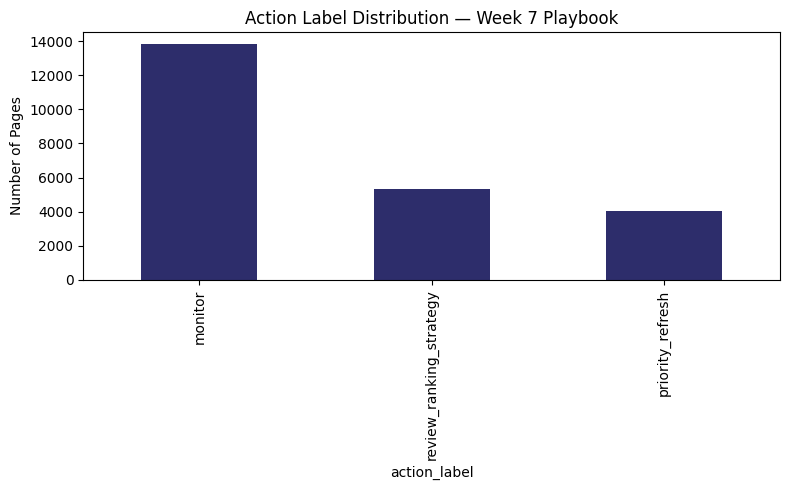

Figure saved to work/figures/w07_action_distribution.png


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Export ranked queue (stays out of git — regenerated each run)
os.makedirs("work/outputs", exist_ok=True)
ranked_queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Queue exported: {len(ranked_queue)} rows")

# Export metrics JSON (this DOES get committed — it's the receipt)
metrics = {
    "week": "w07_action_playbook",
    "model_precision_at_50": round(float(p50), 4),
    "total_pages_scored": int(len(ranked_queue)),
    "action_distribution": ranked_queue["action_label"].value_counts().to_dict(),
    "train_test_split": "client-grouped, March 2026 features -> April 2026 label"
}
with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Metrics JSON saved:")
print(json.dumps(metrics, indent=2))

# Export a figure to reuse in the paper
import matplotlib.pyplot as plt
os.makedirs("work/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5))
ranked_queue["action_label"].value_counts().plot(kind="bar", ax=ax, color="#2d2d6b")
ax.set_title("Action Label Distribution — Week 7 Playbook")
ax.set_ylabel("Number of Pages")
plt.tight_layout()
plt.savefig("work/figures/w07_action_distribution.png", dpi=150)
plt.show()
print("Figure saved to work/figures/w07_action_distribution.png")

**Exports for the paper:**
- `work/outputs/action_playbook_queue.csv` — the ranked queue (regenerated
  each run, stays out of git by design)
- `work/outputs/w07_metrics.json` — committed; the receipt behind this
  week's numbers
- `work/figures/w07_action_distribution.png` — committed; reused directly
  in the paper's Recommendations section

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.